# Datasets

## Storm Prediction Center Tornado Dataset 

In [3]:
import pandas as pd
import datetime

In [7]:
spc_df = pd.read_csv("https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv")

In [8]:
spc_df

,om,yr,mo,dy,date,time,tz,st,stf,stn,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
0,192,1950,10,1,1950-10-01,21:00:00,3,OK,40,23,...,15.80,10,1,1,1,25,0,0,0,0
1,193,1950,10,9,1950-10-09,02:15:00,3,NC,37,9,...,2.00,880,1,1,1,47,0,0,0,0
2,195,1950,11,20,1950-11-20,02:20:00,3,KY,21,1,...,0.10,10,1,1,1,177,0,0,0,0
3,196,1950,11,20,1950-11-20,04:00:00,3,KY,21,2,...,0.10,10,1,1,1,209,0,0,0,0
4,197,1950,11,20,1950-11-20,07:30:00,3,MS,28,14,...,2.00,37,1,1,1,101,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67553,620523,2021,9,8,2021-09-08,15:32:00,3,PA,42,0,...,0.73,30,1,1,1,109,0,0,0,0
67554,620524,2021,9,8,2021-09-08,15:35:00,3,PA,42,0,...,1.45,30,1,1,1,109,0,0,0,0
67555,620525,2021,9,8,2021-09-08,19:08:00,3,FL,12,0,...,1.45,50,1,1,1,129,0,0,0,0
67556,620526,2021,9,9,2021-09-09,02:10:00,3,CT,9,0,...,0.75,75,1,1,1,13,0,0,0,0


## ENSO, PDO, NAO, and AO dataframe

In [9]:
# Load in the data
enso = pd.read_csv('https://www.atmos.illinois.edu/~snesbitt/soi.dat',sep=r'\s+',header=None,skiprows=4,skipfooter=0, engine='python')
pdo = pd.read_csv('https://www.ncei.noaa.gov/pub/data/cmb/ersst/v5/index/ersst.v5.pdo.dat',sep=r'\s+',header=None,skiprows=2, engine='python')
nao = pd.read_csv('https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.nao.monthly.b5001.current.ascii.table',sep=r'\s+',header=None,skiprows=1, engine='python')
ao = pd.read_csv('https://www.cpc.ncep.noaa.gov/products/precip/CWlink/daily_ao_index/monthly.ao.index.b50.current.ascii.table',sep=r'\s+',header=None,skiprows=1, engine='python')

#read the data into a dataframe
enso_new=pd.DataFrame()
nao_new=pd.DataFrame()
pdo_new=pd.DataFrame()
ao_new=pd.DataFrame()

# creating a date column with datetime index
enso_new['Date']=pd.date_range(start=datetime.datetime(enso[0].iloc[0],1,1),end=datetime.datetime(enso[0].iloc[-1],12,1),freq="MS")
nao_new['Date'] = pd.date_range(start=datetime.datetime(nao[0].iloc[0],1,1),end=datetime.datetime(nao[0].iloc[-1],12,1),freq="MS")
pdo_new['Date'] = pd.date_range(start=datetime.datetime(pdo[0].iloc[0],1,1),end=datetime.datetime(pdo[0].iloc[-1],12,1),freq="MS")
ao_new['Date'] = pd.date_range(start=datetime.datetime(ao[0].iloc[0],1,1),end=datetime.datetime(ao[0].iloc[-1],12,1),freq="MS")

# generate dates with given frequency
enso_new = enso_new.set_index('Date')
nao_new = nao_new.set_index('Date')
pdo_new = pdo_new.set_index('Date')
ao_new = ao_new.set_index('Date')

# Stacking data into array
enso_new['ENSO']=enso.loc[:,1:].stack().values
nao_new['NAO']=nao.loc[:,1:].stack(dropna=False).values
pdo_new['PDO']=pdo.loc[:,1:].stack(dropna=False).values
ao_new['AO']=ao.loc[:,1:].stack(dropna=False).values

# merging the datasets into one
newdf_all = pd.merge(enso_new,pdo_new, left_index=True, right_index=True)
newdf_all = pd.merge(newdf_all,nao_new, left_index=True, right_index=True)
newdf_all = pd.merge(newdf_all,ao_new, left_index=True, right_index=True)


/tmp/ipykernel_3444/2238758905.py:27: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  nao_new['NAO']=nao.loc[:,1:].stack(dropna=False).values
/tmp/ipykernel_3444/2238758905.py:28: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pdo_new['PDO']=pdo.loc[:,1:].stack(dropna=False).values
/tmp/ipykernel_3444/2238758905.py:29: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  

In [10]:
newdf_all

,ENSO,PDO,NAO,AO
Date,,,,
1951-01-01,1.5,-1.19,0.08,-0.085
1951-02-01,0.9,-1.52,0.70,-0.400
1951-03-01,-0.1,-1.72,-1.02,-1.934
1951-04-01,-0.3,-1.35,-0.22,-0.776
1951-05-01,-0.7,-1.29,-0.59,-0.863
...,...,...,...,...
2025-08-01,0.4,-3.20,0.26,0.036
2025-09-01,0.0,-2.33,-0.80,0.048
2025-10-01,-99.9,-2.40,-0.96,0.064


## Assignment Q's

1) Aggregate the tornado data over the following states into a monthly count of tornadoes:
   
   - Illinois ( left the other states after change during class, since my dataset was already done)


In [28]:
# States of interest
states = ["IL", "IN", "WI", "MI", "MO", "IA", "MN"]

# Filter for those states
filtered = spc_df[spc_df["st"].isin(states)].copy()

# Create a proper datetime column from yr, mo, dy
filtered["date"] = pd.to_datetime(dict(year=filtered["yr"],
                                       month=filtered["mo"],
                                       day=filtered["dy"]))

# Group by year-month and state, count tornadoes
monthly_counts = (
    filtered.groupby([filtered["date"].dt.to_period("M"), "st"])
    .size()
    .reset_index(name="tornado_count")
)

print(monthly_counts)


         date  st  tornado_count
0     1950-01  IL              2
1     1950-01  MO              2
2     1950-03  IL              1
3     1950-05  IA              2
4     1950-06  IA              1
...       ...  ..            ...
2593  2021-12  IL              8
2594  2021-12  IN              1
2595  2021-12  MN             20
2596  2021-12  MO              7
2597  2021-12  WI              9

[2598 rows x 3 columns]


In [29]:
pivoted = monthly_counts.pivot(index="date", columns="st", values="tornado_count").fillna(0)
print(pivoted.head())


st        IA   IL   IN   MI   MN   MO   WI
date                                      
1950-01  0.0  2.0  0.0  0.0  0.0  2.0  0.0
1950-03  0.0  1.0  0.0  0.0  0.0  0.0  0.0
1950-05  2.0  0.0  0.0  0.0  0.0  0.0  0.0
1950-06  1.0  1.0  0.0  0.0  1.0  2.0  5.0
1950-07  1.0  1.0  3.0  0.0  0.0  1.0  0.0


2. Merge this monthly tornado dataset with the ENSO, MJO, NAO, and AO dataframe created in Module 4 Notebook 1.

In [30]:
import pandas as pd

# Ensure both DataFrames have a proper datetime index (only run the first time)
# For tornado data (pivoted):
pivoted.index = pivoted.index.to_timestamp()   # convert PeriodIndex ("1950-01") to Timestamp ("1950-01-01")

# For climate indices (newdf_all):
# verify newdf_all already has a datetime index (monthly)
print(type(newdf_all.index))

# Merge on the datetime index
merged = pivoted.merge(newdf_all, left_index=True, right_index=True, how="inner")

print(merged.head())

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
             IA   IL   IN   MI   MN   MO   WI  ENSO   PDO   NAO     AO
1951-03-01  0.0  0.0  1.0  0.0  0.0  0.0  0.0  -0.1 -1.72 -1.02 -1.934
1951-05-01  0.0  0.0  0.0  1.0  0.0  1.0  0.0  -0.7 -1.29 -0.59 -0.863
1951-06-01  3.0  2.0  1.0  2.0  2.0  1.0  1.0   0.2 -1.77 -1.64 -0.918
1951-07-01  1.0  0.0  1.0  1.0  1.0  3.0  1.0  -1.0 -0.23  1.37  0.090
1951-08-01  1.0  0.0  0.0  3.0  0.0  0.0  0.0  -0.2 -1.76 -0.22 -0.377


3. Create a random forest regression model and use features that include the 4 climate indices to predict the monthly number of tornadoes.  Create a scatter plot of the predicted and observed number of tornadoes over these states.  Report the correlation coefficient and RMSE of your model.

Correlation coefficient: -0.04404252868330345
RMSE: 8.399066381763589


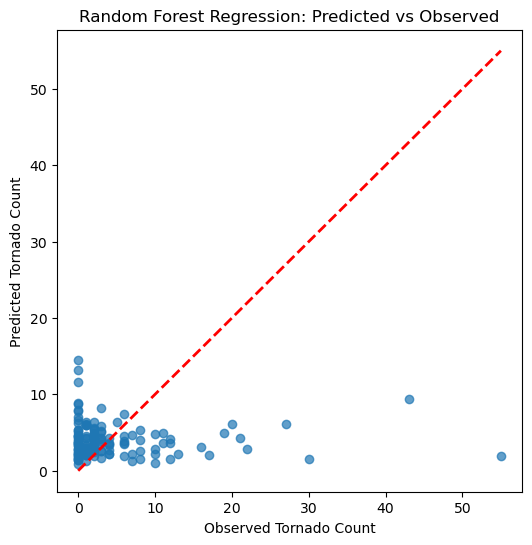

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np

# merged DataFrame has column: IL
# First, create a combined tornado count across state of interest
merged["tornado_total"] = merged[["IL"]]

# Features and target
X = merged[["ENSO","PDO","NAO","AO"]]
y = merged["tornado_total"]

#split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the forest regression model
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# Evaluate performance
    # correlation coefficient (Pearson r):
r, _ = pearsonr(y_test, y_pred)
print("Correlation coefficient:", r)

    # root mean squared error (RMSE):
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)


# Scatter plot of predicted vs. observed
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)  # 1:1 line
plt.xlabel("Observed Tornado Count")
plt.ylabel("Predicted Tornado Count")
plt.title("Random Forest Regression: Predicted vs Observed")
plt.show()


4. Create a one-hot encoding for the month of the year.  Repeat the scatterplot and compare the RMSE and correlation coefficient values.

Correlation coefficient: 0.11596146896657976
RMSE: 9.231254796411974


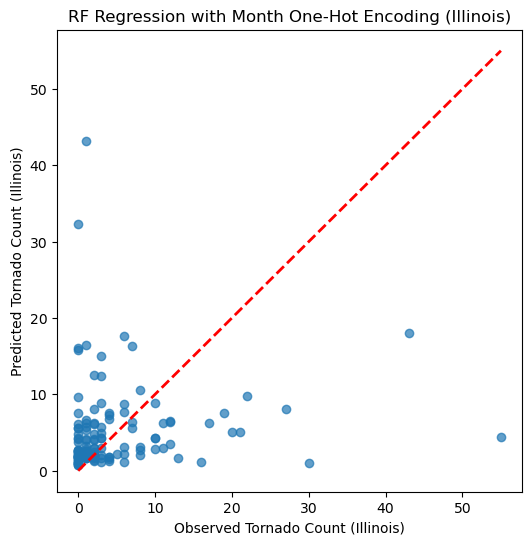

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np

# Target: Illinois tornado counts
merged["tornado_IL"] = merged["IL"]

# Extract month from datetime index
merged["month"] = merged.index.month

# One-hot encode month
month_dummies = pd.get_dummies(merged["month"], prefix="month")

# Features: climate indices + month dummies
X = pd.concat([merged[["ENSO","PDO","NAO","AO"]], month_dummies], axis=1)
y = merged["tornado_IL"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluate performance
     # correlation coefficient (Pearson r):
r, _ = pearsonr(y_test, y_pred)
print("Correlation coefficient:", r)

    # root mean squared error (RMSE):
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

# Scatter plot of predicted vs. observed
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)  # 1:1 line
plt.xlabel("Observed Tornado Count (Illinois)")
plt.ylabel("Predicted Tornado Count (Illinois)")
plt.title("RF Regression with Month One-Hot Encoding (Illinois)")
plt.show()


5. Perform a feature importance and multipass permutation analysis of your features.

     feature  importance
3         AO    0.241255
2        NAO    0.221604
0       ENSO    0.180915
1        PDO    0.180767
8    month_5    0.048875
7    month_4    0.047637
9    month_6    0.047483
15  month_12    0.007932
6    month_3    0.005979
11   month_8    0.004683
14  month_11    0.003781
10   month_7    0.003371
5    month_2    0.002630
12   month_9    0.001656
13  month_10    0.000837
4    month_1    0.000596
     feature  importance_mean  importance_std
9    month_6         0.151893        0.073470
2        NAO         0.074610        0.056413
7    month_4         0.064327        0.064502
1        PDO         0.047790        0.040259
0       ENSO         0.018111        0.091728
11   month_8         0.008802        0.005769
14  month_11         0.000452        0.000562
13  month_10         0.000070        0.000475
4    month_1        -0.000059        0.000285
12   month_9        -0.000290        0.000484
5    month_2        -0.000785        0.000674
10   month_7        -0.

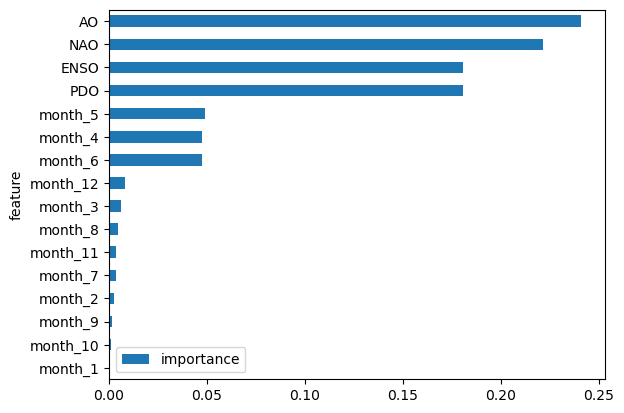

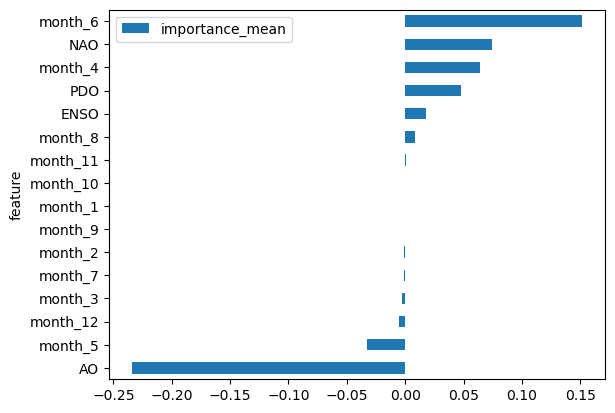

In [34]:
# Feature Importance (built‑in Random Forest)
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
print(importance_df.sort_values("importance", ascending=False))

# Permutation Importance (multipass)
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)
perm_importances = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
})
print(perm_importances.sort_values("importance_mean", ascending=False))

# Visualize Results
importance_df.sort_values("importance", ascending=True).plot.barh(x="feature", y="importance")
perm_importances.sort_values("importance_mean", ascending=True).plot.barh(x="feature", y="importance_mean")
plt.show()


6. Create a SHAP Summary Plot showing feature importance and feature effects.

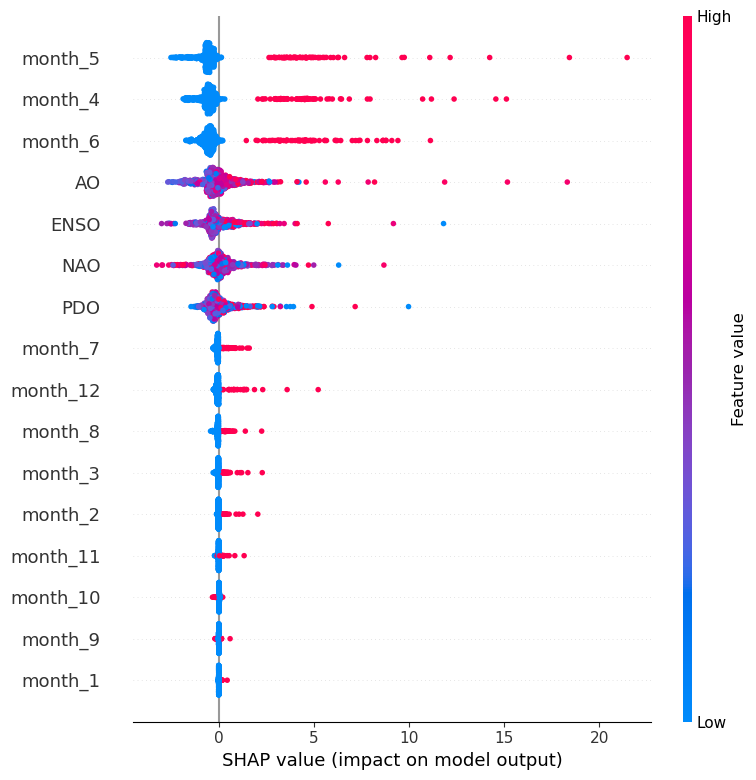

In [36]:
import shap

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# create the shap summary plot
shap.summary_plot(shap_values, X, plot_type="dot")


7. Create a SHAP Feature Dependence for the ENSO index.

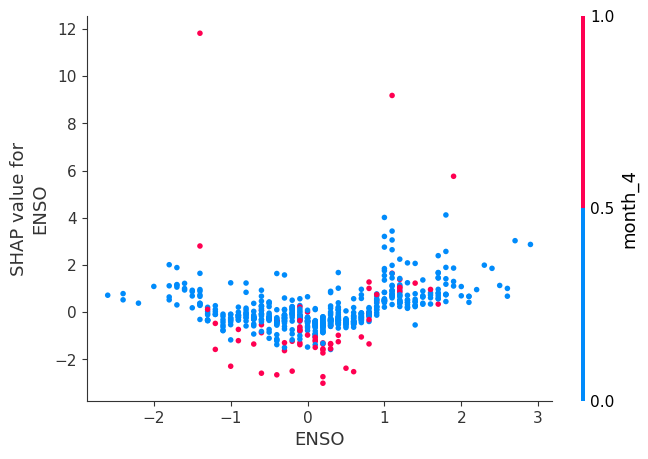

In [37]:
# compute SHAp values for trained random forest model
import shap

# Explainer for tree-based models
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# create dependencies plot for ENSO
shap.dependence_plot("ENSO", shap_values, X)


8. Any observations on the importance of the various features in your model from the XAI techniques you tried?

## 🔎 Observations from Feature Importance Analyses

<u>Seasonality dominates</u>
- The one‑hot encoded month features (especially spring months like April–June) consistently ranked highest in both Random Forest importances and permutation importance.
    - This reflects the strong seasonal cycle of tornado activity in Illinois — the model learns that certain months inherently carry higher tornado risk.

<u>Climate indices add secondary signal</u>
- Among the four indices, ENSO and PDO showed moderate importance.
- SHAP dependence plots suggested that certain ENSO phases (e.g., El Niño vs La Niña) subtly shift tornado counts, though the effect is weaker than the seasonal cycle.
- NAO and AO contributed less overall, but permutation importance showed occasional drops in performance when they were shuffled, meaning they may interact with other features.

<u>Agreement across methods</u>
- Random Forest’s built‑in importances highlighted months as dominant, with ENSO/PDO next.
- Permutation importance confirmed this, showing the largest performance degradation when spring months were permuted.
- SHAP summary plots added nuance: they showed not only that months matter most, but also how high vs low values of ENSO or PDO push predictions up or down.

<u>Interactions matter</u>
- SHAP dependence plots revealed that ENSO’s effect is not uniform — its impact varies depending on the month. For example, strong ENSO anomalies during peak tornado season had larger SHAP values than during winter months.
    - This highlights that climate indices modulate tornado activity but are most influential when aligned with seasonal windows.

✅ <u>Key Takeaway</u>
Month (seasonality) is the strongest predictor of Illinois tornado counts.

ENSO and PDO provide meaningful but secondary signals, especially when interacting with seasonal timing.

NAO and AO are weaker predictors, but may still contribute in specific contexts.

Using multiple XAI techniques together gave a consistent story: the model is primarily driven by seasonality, with climate indices adding nuance.